In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [2]:
# Load all 4 datasets
def load_jsonl(filename):
    data = []
    with open(filename, 'r') as f:
        for line in f:
            data.append(json.loads(line))
    return pd.DataFrame(data)

# Load datasets
df_jml_gpt4 = load_jsonl('jml_gpt4.jsonl')
df_jml_sonnet = load_jsonl('jml_sonnet.jsonl')
df_maple_gpt4 = load_jsonl('maple_gpt4.jsonl')
df_maple_sonnet = load_jsonl('maple_sonnet.jsonl')

print(f"JML GPT-4 shape: {df_jml_gpt4.shape}")
print(f"JML Sonnet shape: {df_jml_sonnet.shape}")
print(f"Maple GPT-4 shape: {df_maple_gpt4.shape}")
print(f"Maple Sonnet shape: {df_maple_sonnet.shape}")

# Combine class_name and feature_name into a single identifier column
for df in [df_jml_gpt4, df_jml_sonnet, df_maple_gpt4, df_maple_sonnet]:
    df['class_feature'] = df['class_name'] + '.' + df['feature_name']
    # Drop the original separate columns
    df.drop(columns=['class_name', 'feature_name'], inplace=True)

# Add dataset identifier to each dataframe
df_jml_gpt4['dataset'] = 'JML'
df_jml_sonnet['dataset'] = 'JML'
df_maple_gpt4['dataset'] = 'Maple'
df_maple_sonnet['dataset'] = 'Maple'

df_jml_gpt4.head()


JML GPT-4 shape: (10, 10)
JML Sonnet shape: (10, 10)
Maple GPT-4 shape: (26, 10)
Maple Sonnet shape: (26, 10)


,model,llm_interactions,success,max_retries_reached,final_status,interactions,code_changes,total_elapsed_time_seconds,class_feature,dataset
0,gpt-4o-mini,1,True,False,Verification passed after 1 LLM interaction(s),"[{'interaction_number': 1, 'error_message': ' ...","[{'change_number': 1, 'before_code': ' Resu...",18.436706,LCM_1.div,JML
1,gpt-4o-mini,1,True,False,Verification passed after 1 LLM interaction(s),"[{'interaction_number': 1, 'error_message': ' ...","[{'change_number': 1, 'before_code': ' if a...",21.940497,LCM_10.lcm,JML
2,gpt-4o-mini,2,True,False,Verification passed after 2 LLM interaction(s),"[{'interaction_number': 1, 'error_message': ' ...","[{'change_number': 1, 'before_code': ' Resu...",16.490185,LCM_11.div,JML
3,gpt-4o-mini,1,True,False,Verification passed after 1 LLM interaction(s),"[{'interaction_number': 1, 'error_message': ' ...","[{'change_number': 1, 'before_code': ' if a...",22.035512,LCM_12.lcm,JML
4,gpt-4o-mini,1,True,False,Verification passed after 1 LLM interaction(s),"[{'interaction_number': 1, 'error_message': ' ...","[{'change_number': 1, 'before_code': ' if a...",19.713888,LCM_13.lcm,JML


In [3]:
# Join within each dataset, then union the results
# JML dataset: Join GPT-4 and Sonnet
df_jml_gpt4_join = df_jml_gpt4[['class_feature', 'llm_interactions', 'total_elapsed_time_seconds', 'success']].copy()
df_jml_gpt4_join = df_jml_gpt4_join.rename(columns={
    'llm_interactions': 'llm_interactions_gpt4',
    'total_elapsed_time_seconds': 'time_seconds_gpt4',
    'success': 'success_gpt4'
})

df_jml_sonnet_join = df_jml_sonnet[['class_feature', 'llm_interactions', 'total_elapsed_time_seconds', 'success']].copy()
df_jml_sonnet_join = df_jml_sonnet_join.rename(columns={
    'llm_interactions': 'llm_interactions_sonnet',
    'total_elapsed_time_seconds': 'time_seconds_sonnet',
    'success': 'success_sonnet'
})

df_jml_joined = pd.merge(df_jml_gpt4_join, df_jml_sonnet_join, on='class_feature', how='outer')
df_jml_joined['dataset'] = 'JML'
df_jml_joined['interaction_diff'] = df_jml_joined['llm_interactions_gpt4'] - df_jml_joined['llm_interactions_sonnet']
df_jml_joined['time_diff'] = df_jml_joined['time_seconds_gpt4'] - df_jml_joined['time_seconds_sonnet']

# Maple dataset: Join GPT-4 and Sonnet
df_maple_gpt4_join = df_maple_gpt4[['class_feature', 'llm_interactions', 'total_elapsed_time_seconds', 'success']].copy()
df_maple_gpt4_join = df_maple_gpt4_join.rename(columns={
    'llm_interactions': 'llm_interactions_gpt4',
    'total_elapsed_time_seconds': 'time_seconds_gpt4',
    'success': 'success_gpt4'
})

df_maple_sonnet_join = df_maple_sonnet[['class_feature', 'llm_interactions', 'total_elapsed_time_seconds', 'success']].copy()
df_maple_sonnet_join = df_maple_sonnet_join.rename(columns={
    'llm_interactions': 'llm_interactions_sonnet',
    'total_elapsed_time_seconds': 'time_seconds_sonnet',
    'success': 'success_sonnet'
})

df_maple_joined = pd.merge(df_maple_gpt4_join, df_maple_sonnet_join, on='class_feature', how='outer')
df_maple_joined['dataset'] = 'Maple'
df_maple_joined['interaction_diff'] = df_maple_joined['llm_interactions_gpt4'] - df_maple_joined['llm_interactions_sonnet']
df_maple_joined['time_diff'] = df_maple_joined['time_seconds_gpt4'] - df_maple_joined['time_seconds_sonnet']

# Union the two joined datasets
df_all = pd.concat([df_jml_joined, df_maple_joined], ignore_index=True)
df_all['interaction_diff'] = df_all['llm_interactions_gpt4'] - df_all['llm_interactions_sonnet']
df_all['time_diff'] = df_all['time_seconds_gpt4'] - df_all['time_seconds_sonnet']

print(f"JML joined shape: {df_jml_joined.shape}")
print(f"Maple joined shape: {df_maple_joined.shape}")
print(f"Combined (union) DataFrame shape: {df_all.shape}")
df_all.head()


JML joined shape: (10, 10)
Maple joined shape: (26, 10)
Combined (union) DataFrame shape: (36, 10)


,class_feature,llm_interactions_gpt4,time_seconds_gpt4,success_gpt4,llm_interactions_sonnet,time_seconds_sonnet,success_sonnet,dataset,interaction_diff,time_diff
0,LCM_1.div,1,18.436706,True,1,20.433337,True,JML,0,-1.996631
1,LCM_10.lcm,1,21.940497,True,1,19.017862,True,JML,0,2.922635
2,LCM_11.div,2,16.490185,True,1,11.322781,True,JML,1,5.167404
3,LCM_12.lcm,1,22.035512,True,1,16.798697,True,JML,0,5.236814
4,LCM_13.lcm,1,19.713888,True,2,40.053026,True,JML,-1,-20.339138


In [4]:
# Preview the joined datasets
print("JML joined dataset (first 5 rows):")
df_jml_joined.head()
print("\nMaple joined dataset (first 5 rows):")
df_maple_joined.head()


JML joined dataset (first 5 rows):

Maple joined dataset (first 5 rows):


,class_feature,llm_interactions_gpt4,time_seconds_gpt4,success_gpt4,llm_interactions_sonnet,time_seconds_sonnet,success_sonnet,dataset,interaction_diff,time_diff
0,MAPLE_RECURSIVE_ABSOLUTE_1.abs,1,7.665138,True,1,9.234017,True,Maple,0,-1.568879
1,MAPLE_RECURSIVE_ABSOLUTE_2.abs,1,7.098912,True,1,10.857702,True,Maple,0,-3.758790
2,MAPLE_RECURSIVE_CONSEQ_1.sum,3,28.531213,True,1,10.883398,True,Maple,2,17.647815
3,MAPLE_RECURSIVE_CONSEQ_2.sum,10,75.988991,False,2,32.135457,True,Maple,8,43.853534
4,MAPLE_RECURSIVE_CONSEQ_3.sum,3,23.978124,True,2,30.606134,True,Maple,1,-6.628011


In [5]:
# Summary statistics: Model comparison for JML dataset
print("=" * 60)
print("JML DATASET - Model Comparison (GPT-4 vs Sonnet)")
print("=" * 60)

# Filter to cases where both models have data
df_jml_both = df_jml_joined.dropna(subset=['llm_interactions_gpt4', 'llm_interactions_sonnet'])

print(f"\nTotal cases: {len(df_jml_joined)}")
print(f"Cases with both models: {len(df_jml_both)}")

if len(df_jml_both) > 0:
    print(f"\nGPT-4 Statistics (where both models exist):")
    print(df_jml_both['llm_interactions_gpt4'].describe())
    print(f"\nSonnet Statistics (where both models exist):")
    print(df_jml_both['llm_interactions_sonnet'].describe())
    print(f"\nDifference (GPT-4 - Sonnet):")
    print(df_jml_both['interaction_diff'].describe())

    print(f"\nCases where GPT-4 required fewer interactions: {(df_jml_both['interaction_diff'] < 0).sum()}")
    print(f"Cases where Sonnet required fewer interactions: {(df_jml_both['interaction_diff'] > 0).sum()}")
    print(f"Cases with equal interactions: {(df_jml_both['interaction_diff'] == 0).sum()}")
    print(f"\nMean interactions - GPT-4: {df_jml_both['llm_interactions_gpt4'].mean():.2f}")
    print(f"Mean interactions - Sonnet: {df_jml_both['llm_interactions_sonnet'].mean():.2f}")
    print(f"Mean difference: {df_jml_both['interaction_diff'].mean():.2f}")
    
    print(f"\nTime Statistics (where both models exist):")
    print(f"GPT-4 Time Statistics:")
    print(df_jml_both['time_seconds_gpt4'].describe())
    print(f"\nSonnet Time Statistics:")
    print(df_jml_both['time_seconds_sonnet'].describe())
    print(f"\nTime Difference (GPT-4 - Sonnet):")
    print(df_jml_both['time_diff'].describe())
    print(f"\nMean time - GPT-4: {df_jml_both['time_seconds_gpt4'].mean():.2f} seconds")
    print(f"Mean time - Sonnet: {df_jml_both['time_seconds_sonnet'].mean():.2f} seconds")
    print(f"Mean time difference: {df_jml_both['time_diff'].mean():.2f} seconds")


JML DATASET - Model Comparison (GPT-4 vs Sonnet)

Total cases: 10
Cases with both models: 10

GPT-4 Statistics (where both models exist):
count    10.000000
mean      3.800000
std       4.289522
min       1.000000
25%       1.000000
50%       1.000000
75%       8.000000
max      10.000000
Name: llm_interactions_gpt4, dtype: float64

Sonnet Statistics (where both models exist):
count    10.000000
mean      1.100000
std       0.316228
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       2.000000
Name: llm_interactions_sonnet, dtype: float64

Difference (GPT-4 - Sonnet):
count    10.000000
mean      2.700000
std       4.372896
min      -1.000000
25%       0.000000
50%       0.000000
75%       7.000000
max       9.000000
Name: interaction_diff, dtype: float64

Cases where GPT-4 required fewer interactions: 1
Cases where Sonnet required fewer interactions: 4
Cases with equal interactions: 5

Mean interactions - GPT-4: 3.80
Mean interactions - Sonnet: 1.10
Me

In [6]:
# Summary statistics: Model comparison for Maple dataset
print("\n" + "=" * 60)
print("MAPLE DATASET - Model Comparison (GPT-4 vs Sonnet)")
print("=" * 60)

# Filter to cases where both models have data
df_maple_both = df_maple_joined.dropna(subset=['llm_interactions_gpt4', 'llm_interactions_sonnet'])

print(f"\nTotal cases: {len(df_maple_joined)}")
print(f"Cases with both models: {len(df_maple_both)}")

if len(df_maple_both) > 0:
    print(f"\nGPT-4 Statistics (where both models exist):")
    print(df_maple_both['llm_interactions_gpt4'].describe())
    print(f"\nSonnet Statistics (where both models exist):")
    print(df_maple_both['llm_interactions_sonnet'].describe())
    print(f"\nDifference (GPT-4 - Sonnet):")
    print(df_maple_both['interaction_diff'].describe())

    print(f"\nCases where GPT-4 required fewer interactions: {(df_maple_both['interaction_diff'] < 0).sum()}")
    print(f"Cases where Sonnet required fewer interactions: {(df_maple_both['interaction_diff'] > 0).sum()}")
    print(f"Cases with equal interactions: {(df_maple_both['interaction_diff'] == 0).sum()}")
    print(f"\nMean interactions - GPT-4: {df_maple_both['llm_interactions_gpt4'].mean():.2f}")
    print(f"Mean interactions - Sonnet: {df_maple_both['llm_interactions_sonnet'].mean():.2f}")
    print(f"Mean difference: {df_maple_both['interaction_diff'].mean():.2f}")
    
    print(f"\nTime Statistics (where both models exist):")
    print(f"GPT-4 Time Statistics:")
    print(df_maple_both['time_seconds_gpt4'].describe())
    print(f"\nSonnet Time Statistics:")
    print(df_maple_both['time_seconds_sonnet'].describe())
    print(f"\nTime Difference (GPT-4 - Sonnet):")
    print(df_maple_both['time_diff'].describe())
    print(f"\nMean time - GPT-4: {df_maple_both['time_seconds_gpt4'].mean():.2f} seconds")
    print(f"Mean time - Sonnet: {df_maple_both['time_seconds_sonnet'].mean():.2f} seconds")
    print(f"Mean time difference: {df_maple_both['time_diff'].mean():.2f} seconds")



MAPLE DATASET - Model Comparison (GPT-4 vs Sonnet)

Total cases: 26
Cases with both models: 26

GPT-4 Statistics (where both models exist):
count    26.000000
mean      2.730769
std       3.219412
min       1.000000
25%       1.000000
50%       1.000000
75%       2.000000
max      10.000000
Name: llm_interactions_gpt4, dtype: float64

Sonnet Statistics (where both models exist):
count    26.000000
mean      1.153846
std       0.367946
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       2.000000
Name: llm_interactions_sonnet, dtype: float64

Difference (GPT-4 - Sonnet):
count    26.000000
mean      1.576923
std       3.177081
min      -1.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       9.000000
Name: interaction_diff, dtype: float64

Cases where GPT-4 required fewer interactions: 1
Cases where Sonnet required fewer interactions: 10
Cases with equal interactions: 15

Mean interactions - GPT-4: 2.73
Mean interactions - Sonnet: 1.

In [7]:
# Overall comparison across both datasets
print("=" * 60)
print("OVERALL COMPARISON - Both Datasets Combined")
print("=" * 60)
print(f"\nTotal cases: {len(df_all)}")
print(f"  JML cases: {len(df_jml_joined)}")
print(f"  Maple cases: {len(df_maple_joined)}")

print("\nOverall Statistics - Interactions (GPT-4 vs Sonnet across both datasets):")
print(f"\nGPT-4 Statistics:")
print(df_all['llm_interactions_gpt4'].describe())
print(f"\nSonnet Statistics:")
print(df_all['llm_interactions_sonnet'].describe())
print(f"\nDifference (GPT-4 - Sonnet):")
print(df_all['interaction_diff'].describe())

print(f"\nCases where GPT-4 required fewer interactions: {(df_all['interaction_diff'] < 0).sum()}")
print(f"Cases where Sonnet required fewer interactions: {(df_all['interaction_diff'] > 0).sum()}")
print(f"Cases with equal interactions: {(df_all['interaction_diff'] == 0).sum()}")
print(f"\nMean interactions - GPT-4: {df_all['llm_interactions_gpt4'].mean():.2f}")
print(f"Mean interactions - Sonnet: {df_all['llm_interactions_sonnet'].mean():.2f}")
print(f"Mean difference: {df_all['interaction_diff'].mean():.2f}")

print("\n" + "=" * 60)
print("Overall Statistics - Time (GPT-4 vs Sonnet across both datasets):")
print("=" * 60)
print(f"\nGPT-4 Time Statistics:")
print(df_all['time_seconds_gpt4'].describe())
print(f"\nSonnet Time Statistics:")
print(df_all['time_seconds_sonnet'].describe())
print(f"\nTime Difference (GPT-4 - Sonnet):")
print(df_all['time_diff'].describe())

print(f"\nCases where GPT-4 was faster: {(df_all['time_diff'] < 0).sum()}")
print(f"Cases where Sonnet was faster: {(df_all['time_diff'] > 0).sum()}")
print(f"Cases with equal time: {(df_all['time_diff'] == 0).sum()}")
print(f"\nMean time - GPT-4: {df_all['time_seconds_gpt4'].mean():.2f} seconds")
print(f"Mean time - Sonnet: {df_all['time_seconds_sonnet'].mean():.2f} seconds")
print(f"Mean time difference: {df_all['time_diff'].mean():.2f} seconds")

df_all.head()


OVERALL COMPARISON - Both Datasets Combined

Total cases: 36
  JML cases: 10
  Maple cases: 26

Overall Statistics - Interactions (GPT-4 vs Sonnet across both datasets):

GPT-4 Statistics:
count    36.000000
mean      3.027778
std       3.517191
min       1.000000
25%       1.000000
50%       1.000000
75%       2.250000
max      10.000000
Name: llm_interactions_gpt4, dtype: float64

Sonnet Statistics:
count    36.000000
mean      1.138889
std       0.350736
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       2.000000
Name: llm_interactions_sonnet, dtype: float64

Difference (GPT-4 - Sonnet):
count    36.000000
mean      1.888889
std       3.519560
min      -1.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       9.000000
Name: interaction_diff, dtype: float64

Cases where GPT-4 required fewer interactions: 2
Cases where Sonnet required fewer interactions: 14
Cases with equal interactions: 20

Mean interactions - GPT-4: 3.03
Mean int

,class_feature,llm_interactions_gpt4,time_seconds_gpt4,success_gpt4,llm_interactions_sonnet,time_seconds_sonnet,success_sonnet,dataset,interaction_diff,time_diff
0,LCM_1.div,1,18.436706,True,1,20.433337,True,JML,0,-1.996631
1,LCM_10.lcm,1,21.940497,True,1,19.017862,True,JML,0,2.922635
2,LCM_11.div,2,16.490185,True,1,11.322781,True,JML,1,5.167404
3,LCM_12.lcm,1,22.035512,True,1,16.798697,True,JML,0,5.236814
4,LCM_13.lcm,1,19.713888,True,2,40.053026,True,JML,-1,-20.339138


In [8]:
# Comparison by dataset
print("=" * 60)
print("COMPARISON BY DATASET")
print("=" * 60)

# JML Dataset
print("\nJML Dataset:")
jml_with_both = df_jml_joined.dropna(subset=['llm_interactions_gpt4', 'llm_interactions_sonnet'])
if len(jml_with_both) > 0:
    print(f"  Cases with both models: {len(jml_with_both)}")
    print(f"  Mean GPT-4 interactions: {jml_with_both['llm_interactions_gpt4'].mean():.2f}")
    print(f"  Mean Sonnet interactions: {jml_with_both['llm_interactions_sonnet'].mean():.2f}")
    print(f"  Mean difference: {jml_with_both['interaction_diff'].mean():.2f}")

# Maple Dataset
print("\nMaple Dataset:")
maple_with_both = df_maple_joined.dropna(subset=['llm_interactions_gpt4', 'llm_interactions_sonnet'])
if len(maple_with_both) > 0:
    print(f"  Cases with both models: {len(maple_with_both)}")
    print(f"  Mean GPT-4 interactions: {maple_with_both['llm_interactions_gpt4'].mean():.2f}")
    print(f"  Mean Sonnet interactions: {maple_with_both['llm_interactions_sonnet'].mean():.2f}")
    print(f"  Mean difference: {maple_with_both['interaction_diff'].mean():.2f}")

# Overall comparison
print("\nOverall (both datasets combined):")
all_with_both = df_all.dropna(subset=['llm_interactions_gpt4', 'llm_interactions_sonnet'])
if len(all_with_both) > 0:
    print(f"  Total cases with both models: {len(all_with_both)}")
    print(f"  Mean GPT-4 interactions: {all_with_both['llm_interactions_gpt4'].mean():.2f}")
    print(f"  Mean Sonnet interactions: {all_with_both['llm_interactions_sonnet'].mean():.2f}")
    print(f"  Mean difference: {all_with_both['interaction_diff'].mean():.2f}")

all_with_both_time = df_all.dropna(subset=['time_seconds_gpt4', 'time_seconds_sonnet'])
if len(all_with_both_time) > 0:
    print(f"\n  Time comparison:")
    print(f"  Mean GPT-4 time: {all_with_both_time['time_seconds_gpt4'].mean():.2f} seconds")
    print(f"  Mean Sonnet time: {all_with_both_time['time_seconds_sonnet'].mean():.2f} seconds")
    print(f"  Mean time difference: {all_with_both_time['time_diff'].mean():.2f} seconds")


COMPARISON BY DATASET

JML Dataset:
  Cases with both models: 10
  Mean GPT-4 interactions: 3.80
  Mean Sonnet interactions: 1.10
  Mean difference: 2.70

Maple Dataset:
  Cases with both models: 26
  Mean GPT-4 interactions: 2.73
  Mean Sonnet interactions: 1.15
  Mean difference: 1.58

Overall (both datasets combined):
  Total cases with both models: 36
  Mean GPT-4 interactions: 3.03
  Mean Sonnet interactions: 1.14
  Mean difference: 1.89

  Time comparison:
  Mean GPT-4 time: 35.11 seconds
  Mean Sonnet time: 15.76 seconds
  Mean time difference: 19.36 seconds


In [9]:
# Detailed statistics by dataset
print("=" * 60)
print("DETAILED STATISTICS BY DATASET")
print("=" * 60)

for dataset_name, df_dataset in [('JML', df_jml_joined), ('Maple', df_maple_joined)]:
    print(f"\n{dataset_name} Dataset:")
    print(f"  Total cases: {len(df_dataset)}")
    
    # GPT-4 stats
    gpt4_data = df_dataset['llm_interactions_gpt4'].dropna()
    if len(gpt4_data) > 0:
        print(f"  GPT-4:")
        print(f"    Count: {len(gpt4_data)}")
        print(f"    Mean:  {gpt4_data.mean():.2f}")
        print(f"    Std:   {gpt4_data.std():.2f}")
        print(f"    Min:   {gpt4_data.min():.0f}")
        print(f"    Max:   {gpt4_data.max():.0f}")
    
    # Sonnet stats
    sonnet_data = df_dataset['llm_interactions_sonnet'].dropna()
    if len(sonnet_data) > 0:
        print(f"  Sonnet:")
        print(f"    Count: {len(sonnet_data)}")
        print(f"    Mean:  {sonnet_data.mean():.2f}")
        print(f"    Std:   {sonnet_data.std():.2f}")
        print(f"    Min:   {sonnet_data.min():.0f}")
        print(f"    Max:   {sonnet_data.max():.0f}")
    
    # Difference stats (where both exist)
    diff_data = df_dataset['interaction_diff'].dropna()
    if len(diff_data) > 0:
        print(f"  Difference (GPT-4 - Sonnet):")
        print(f"    Count: {len(diff_data)}")
        print(f"    Mean:  {diff_data.mean():.2f}")
        print(f"    Std:   {diff_data.std():.2f}")
        print(f"    Min:   {diff_data.min():.0f}")
        print(f"    Max:   {diff_data.max():.0f}")


DETAILED STATISTICS BY DATASET

JML Dataset:
  Total cases: 10
  GPT-4:
    Count: 10
    Mean:  3.80
    Std:   4.29
    Min:   1
    Max:   10
  Sonnet:
    Count: 10
    Mean:  1.10
    Std:   0.32
    Min:   1
    Max:   2
  Difference (GPT-4 - Sonnet):
    Count: 10
    Mean:  2.70
    Std:   4.37
    Min:   -1
    Max:   9

Maple Dataset:
  Total cases: 26
  GPT-4:
    Count: 26
    Mean:  2.73
    Std:   3.22
    Min:   1
    Max:   10
  Sonnet:
    Count: 26
    Mean:  1.15
    Std:   0.37
    Min:   1
    Max:   2
  Difference (GPT-4 - Sonnet):
    Count: 26
    Mean:  1.58
    Std:   3.18
    Min:   -1
    Max:   9


In [10]:
# Comprehensive view of the unioned data
print("=" * 60)
print("COMPREHENSIVE VIEW - Unioned Datasets")
print("=" * 60)
print(f"\nTotal class-feature pairs: {len(df_all)}")
print(f"\nColumns: {list(df_all.columns)}")
print(f"\nDataset distribution:")
print(df_all['dataset'].value_counts())
print("\nFirst 10 rows:")
df_all.head(10)


COMPREHENSIVE VIEW - Unioned Datasets

Total class-feature pairs: 36

Columns: ['class_feature', 'llm_interactions_gpt4', 'time_seconds_gpt4', 'success_gpt4', 'llm_interactions_sonnet', 'time_seconds_sonnet', 'success_sonnet', 'dataset', 'interaction_diff', 'time_diff']

Dataset distribution:
dataset
Maple    26
JML      10
Name: count, dtype: int64

First 10 rows:


,class_feature,llm_interactions_gpt4,time_seconds_gpt4,success_gpt4,llm_interactions_sonnet,time_seconds_sonnet,success_sonnet,dataset,interaction_diff,time_diff
0,LCM_1.div,1,18.436706,True,1,20.433337,True,JML,0,-1.996631
1,LCM_10.lcm,1,21.940497,True,1,19.017862,True,JML,0,2.922635
2,LCM_11.div,2,16.490185,True,1,11.322781,True,JML,1,5.167404
3,LCM_12.lcm,1,22.035512,True,1,16.798697,True,JML,0,5.236814
4,LCM_13.lcm,1,19.713888,True,2,40.053026,True,JML,-1,-20.339138
5,LCM_14.lcm,10,175.874859,False,1,19.229783,True,JML,9,156.645076
6,LCM_2.lcm,1,20.484397,True,1,20.512985,True,JML,0,-0.028588
7,LCM_3.lcm,1,22.040372,True,1,19.616437,True,JML,0,2.423935
8,LCM_4.lcm,10,180.233178,False,1,19.757444,True,JML,9,160.475735
9,LCM_5.lcm,10,184.014473,False,1,18.425320,True,JML,9,165.589154


In [11]:
# Overall summary statistics
print("=" * 60)
print("OVERALL SUMMARY STATISTICS")
print("=" * 60)

# Cases where both models have data
df_both_models = df_all.dropna(subset=['llm_interactions_gpt4', 'llm_interactions_sonnet'])
print(f"\nCases with both models: {len(df_both_models)}")

if len(df_both_models) > 0:
    print("\nMean interactions across all configurations:")
    print(f"  GPT-4:     {df_both_models['llm_interactions_gpt4'].mean():.2f}")
    print(f"  Sonnet:    {df_both_models['llm_interactions_sonnet'].mean():.2f}")
    print(f"  Difference: {df_both_models['interaction_diff'].mean():.2f}")
    
    print("\nBy dataset:")
    for dataset_name in ['JML', 'Maple']:
        df_ds = df_both_models[df_both_models['dataset'] == dataset_name]
        if len(df_ds) > 0:
            print(f"\n  {dataset_name}:")
            print(f"    Cases: {len(df_ds)}")
            print(f"    GPT-4 mean: {df_ds['llm_interactions_gpt4'].mean():.2f}")
            print(f"    Sonnet mean: {df_ds['llm_interactions_sonnet'].mean():.2f}")
            print(f"    Difference: {df_ds['interaction_diff'].mean():.2f}")

# Show individual model statistics across all datasets
print("\n" + "-" * 60)
print("Individual Model Statistics - Interactions (across all datasets):")
print("-" * 60)
for model_col, model_name in [('llm_interactions_gpt4', 'GPT-4'), ('llm_interactions_sonnet', 'Sonnet')]:
    if model_col in df_all.columns:
        data = df_all[model_col].dropna()
        if len(data) > 0:
            print(f"\n{model_name}:")
            print(f"  Count: {len(data)}")
            print(f"  Mean:  {data.mean():.2f}")
            print(f"  Std:   {data.std():.2f}")
            print(f"  Min:   {data.min():.0f}")
            print(f"  Max:   {data.max():.0f}")

print("\n" + "-" * 60)
print("Individual Model Statistics - Time (across all datasets):")
print("-" * 60)
for model_col, model_name in [('time_seconds_gpt4', 'GPT-4'), ('time_seconds_sonnet', 'Sonnet')]:
    if model_col in df_all.columns:
        data = df_all[model_col].dropna()
        if len(data) > 0:
            print(f"\n{model_name}:")
            print(f"  Count: {len(data)}")
            print(f"  Mean:  {data.mean():.2f} seconds")
            print(f"  Std:   {data.std():.2f} seconds")
            print(f"  Min:   {data.min():.2f} seconds")
            print(f"  Max:   {data.max():.2f} seconds")


OVERALL SUMMARY STATISTICS

Cases with both models: 36

Mean interactions across all configurations:
  GPT-4:     3.03
  Sonnet:    1.14
  Difference: 1.89

By dataset:

  JML:
    Cases: 10
    GPT-4 mean: 3.80
    Sonnet mean: 1.10
    Difference: 2.70

  Maple:
    Cases: 26
    GPT-4 mean: 2.73
    Sonnet mean: 1.15
    Difference: 1.58

------------------------------------------------------------
Individual Model Statistics - Interactions (across all datasets):
------------------------------------------------------------

GPT-4:
  Count: 36
  Mean:  3.03
  Std:   3.52
  Min:   1
  Max:   10

Sonnet:
  Count: 36
  Mean:  1.14
  Std:   0.35
  Min:   1
  Max:   2

------------------------------------------------------------
Individual Model Statistics - Time (across all datasets):
------------------------------------------------------------

GPT-4:
  Count: 36
  Mean:  35.11 seconds
  Std:   49.58 seconds
  Min:   7.01 seconds
  Max:   184.01 seconds

Sonnet:
  Count: 36
  Mean:  15.

In [12]:
# Display cases with significant differences
print("=" * 60)
print("CASES WITH SIGNIFICANT DIFFERENCES")
print("=" * 60)

# Model differences (where available in both models)
df_jml_both = df_jml_joined.dropna(subset=['llm_interactions_gpt4', 'llm_interactions_sonnet'])
if len(df_jml_both) > 0:
    print("\nJML Dataset - Cases where models differ:")
    jml_diff = df_jml_both[df_jml_both['interaction_diff'] != 0].sort_values('interaction_diff')
    if len(jml_diff) > 0:
        display_cols = ['class_feature', 'llm_interactions_gpt4', 'llm_interactions_sonnet', 'interaction_diff']
        print(jml_diff[display_cols].to_string(index=False))
    else:
        print("  No differences found")

df_maple_both = df_maple_joined.dropna(subset=['llm_interactions_gpt4', 'llm_interactions_sonnet'])
if len(df_maple_both) > 0:
    print("\nMaple Dataset - Cases where models differ:")
    maple_diff = df_maple_both[df_maple_both['interaction_diff'] != 0].sort_values('interaction_diff')
    if len(maple_diff) > 0:
        display_cols = ['class_feature', 'llm_interactions_gpt4', 'llm_interactions_sonnet', 'interaction_diff']
        print(maple_diff[display_cols].to_string(index=False))
    else:
        print("  No differences found")


CASES WITH SIGNIFICANT DIFFERENCES

JML Dataset - Cases where models differ:
class_feature  llm_interactions_gpt4  llm_interactions_sonnet  interaction_diff
   LCM_13.lcm                      1                        2                -1
   LCM_11.div                      2                        1                 1
   LCM_14.lcm                     10                        1                 9
    LCM_4.lcm                     10                        1                 9
    LCM_5.lcm                     10                        1                 9

Maple Dataset - Cases where models differ:
                        class_feature  llm_interactions_gpt4  llm_interactions_sonnet  interaction_diff
          MAPLE_RECURSIVE_SUM_3_2.sum                      1                        2                -1
         MAPLE_RECURSIVE_CONSEQ_3.sum                      3                        2                 1
MAPLE_RECURSIVE_INCREMENT_3.increment                      2                        1  

VISUALIZATION - Model Comparisons


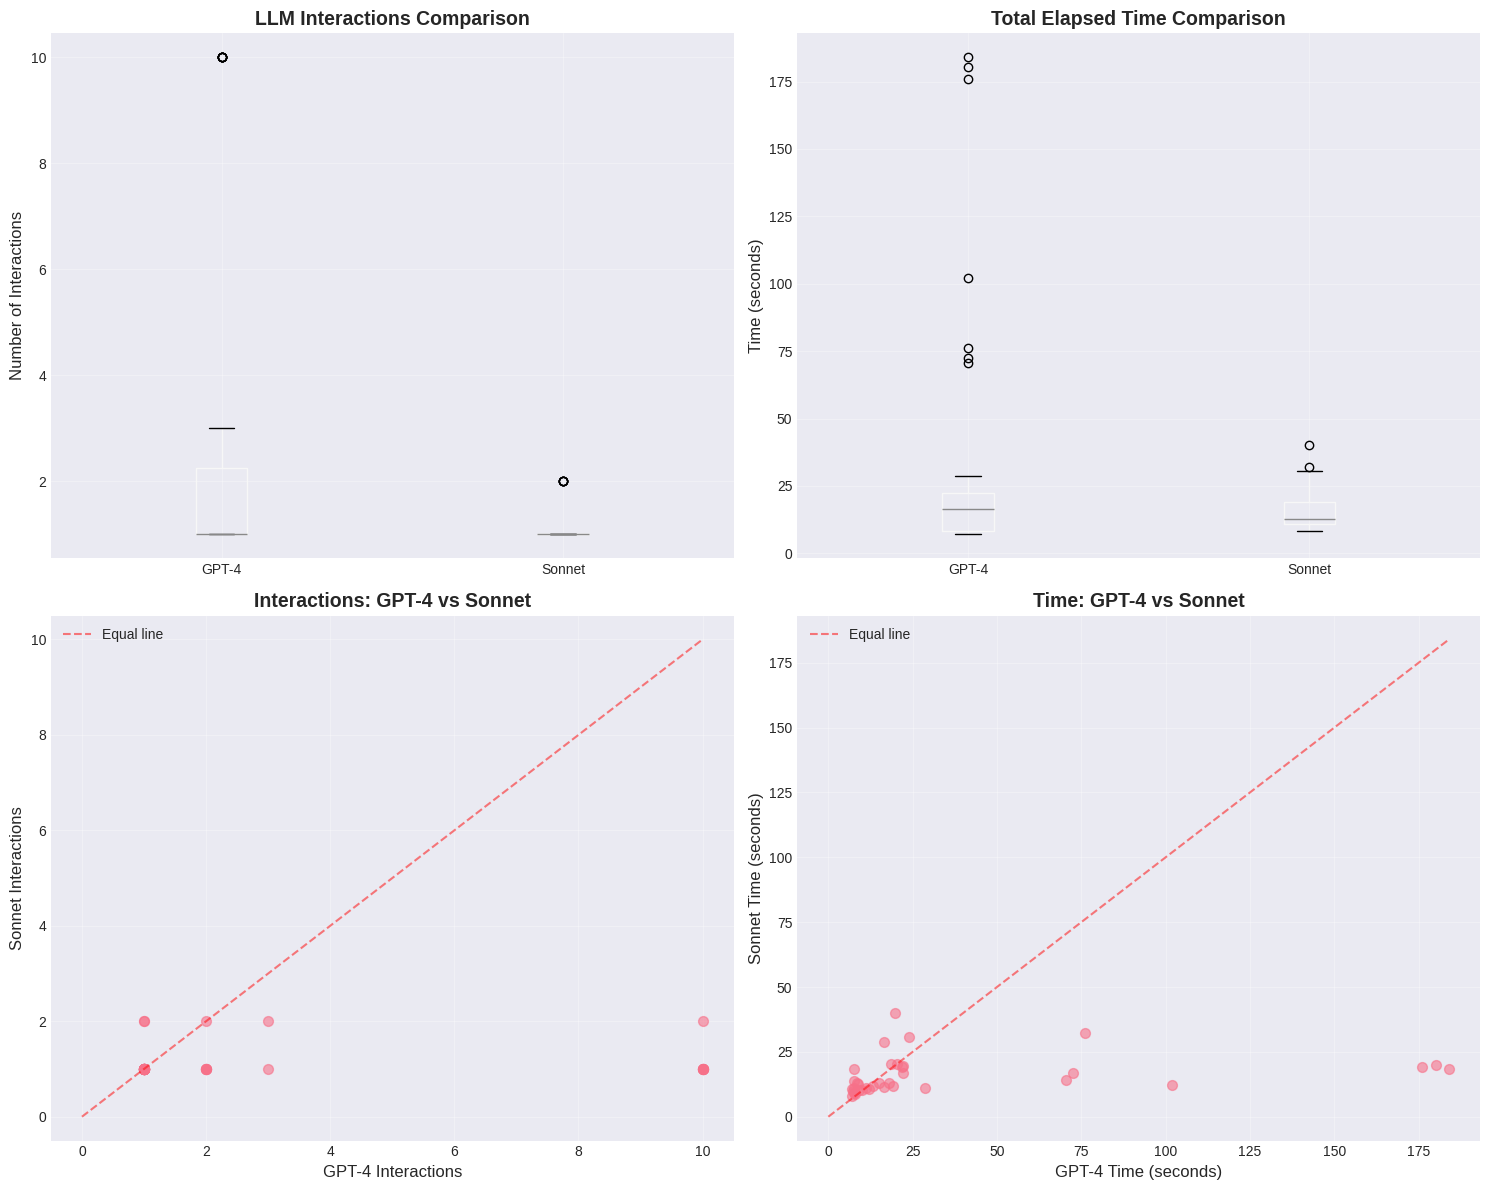


Plots generated for 36 cases with both models


In [13]:
# Visualization: Comparison graphs
print("=" * 60)
print("VISUALIZATION - Model Comparisons")
print("=" * 60)

# Filter to cases where both models have data
df_both_models = df_all.dropna(subset=['llm_interactions_gpt4', 'llm_interactions_sonnet', 'time_seconds_gpt4', 'time_seconds_sonnet'])

if len(df_both_models) > 0:
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Interactions comparison - Box plot
    ax1 = axes[0, 0]
    interaction_data = pd.DataFrame({
        'GPT-4': df_both_models['llm_interactions_gpt4'],
        'Sonnet': df_both_models['llm_interactions_sonnet']
    })
    interaction_data.boxplot(ax=ax1)
    ax1.set_title('LLM Interactions Comparison', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Number of Interactions', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # 2. Time comparison - Box plot
    ax2 = axes[0, 1]
    time_data = pd.DataFrame({
        'GPT-4': df_both_models['time_seconds_gpt4'],
        'Sonnet': df_both_models['time_seconds_sonnet']
    })
    time_data.boxplot(ax=ax2)
    ax2.set_title('Total Elapsed Time Comparison', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Time (seconds)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    # 3. Interactions scatter plot
    ax3 = axes[1, 0]
    ax3.scatter(df_both_models['llm_interactions_gpt4'], df_both_models['llm_interactions_sonnet'], 
                alpha=0.6, s=50)
    # Add diagonal line
    max_val = max(df_both_models['llm_interactions_gpt4'].max(), 
                  df_both_models['llm_interactions_sonnet'].max())
    ax3.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Equal line')
    ax3.set_xlabel('GPT-4 Interactions', fontsize=12)
    ax3.set_ylabel('Sonnet Interactions', fontsize=12)
    ax3.set_title('Interactions: GPT-4 vs Sonnet', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Time scatter plot
    ax4 = axes[1, 1]
    ax4.scatter(df_both_models['time_seconds_gpt4'], df_both_models['time_seconds_sonnet'], 
                alpha=0.6, s=50)
    # Add diagonal line
    max_time = max(df_both_models['time_seconds_gpt4'].max(), 
                   df_both_models['time_seconds_sonnet'].max())
    ax4.plot([0, max_time], [0, max_time], 'r--', alpha=0.5, label='Equal line')
    ax4.set_xlabel('GPT-4 Time (seconds)', fontsize=12)
    ax4.set_ylabel('Sonnet Time (seconds)', fontsize=12)
    ax4.set_title('Time: GPT-4 vs Sonnet', fontsize=14, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nPlots generated for {len(df_both_models)} cases with both models")
else:
    print("No data available for visualization")


VISUALIZATION - Comparison by Dataset


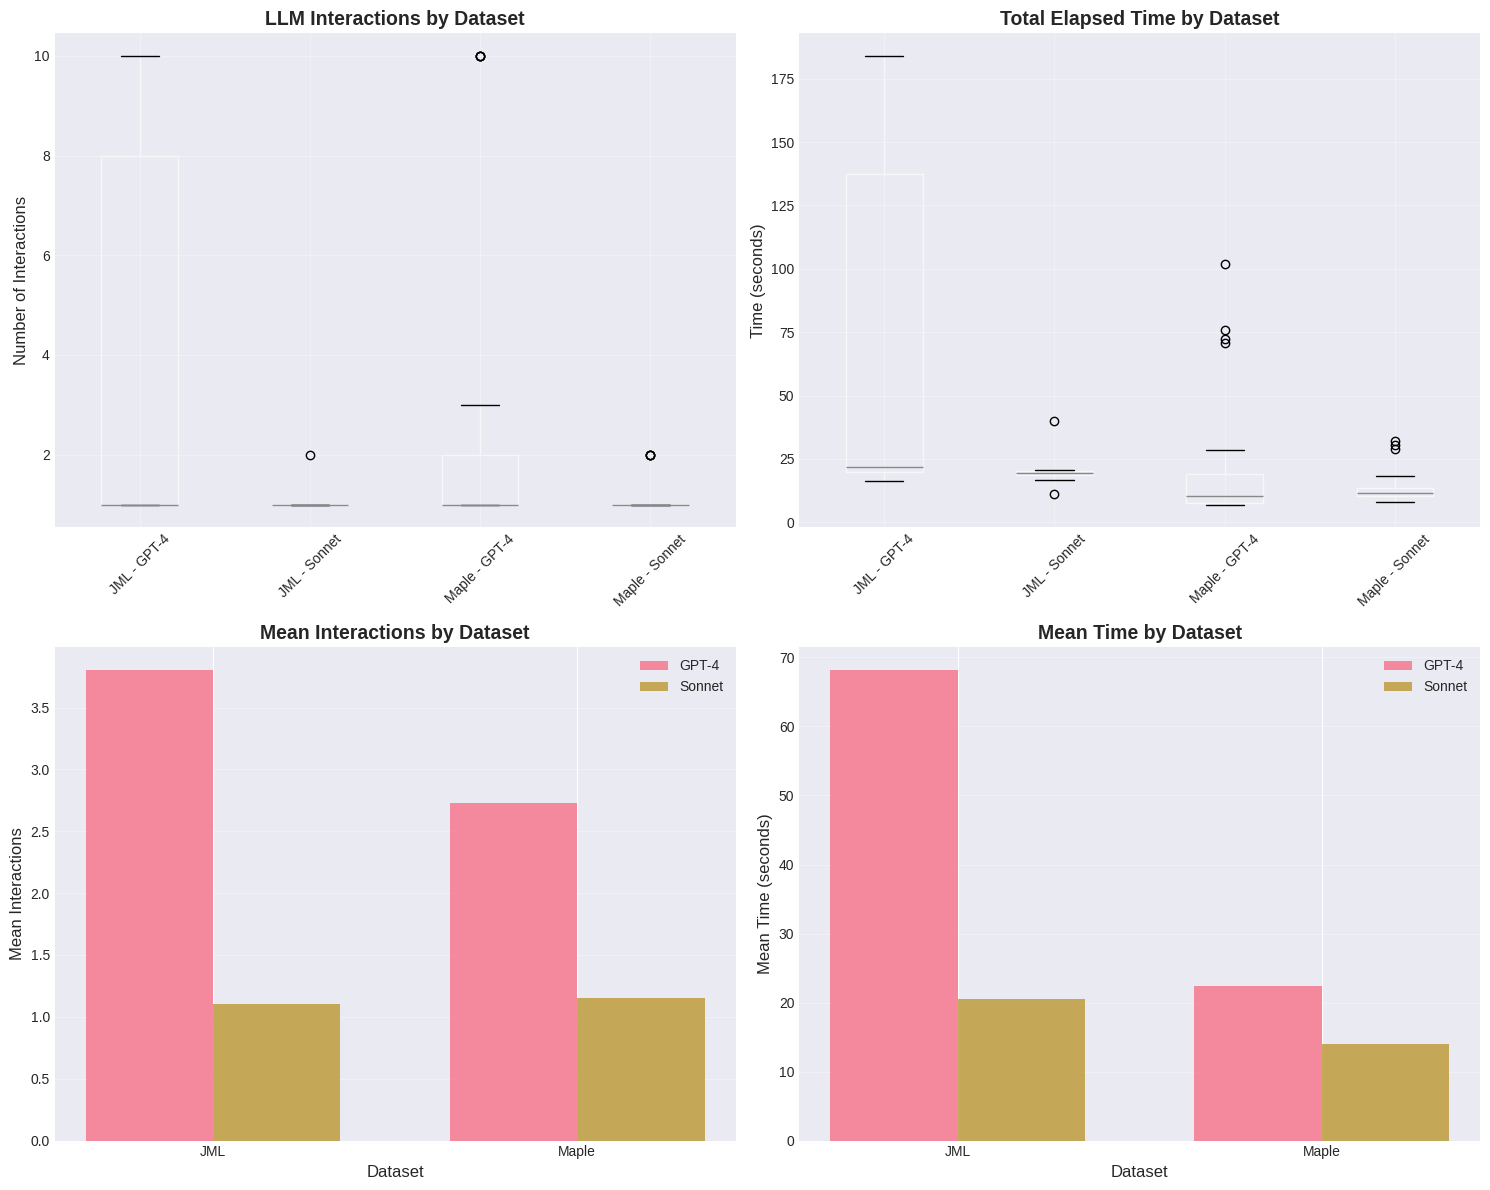


Plots generated:
  JML: 10 cases
  Maple: 26 cases


In [14]:
# Visualization: Comparison by dataset
print("=" * 60)
print("VISUALIZATION - Comparison by Dataset")
print("=" * 60)

# Filter to cases where both models have data, grouped by dataset
jml_both = df_jml_joined.dropna(subset=['llm_interactions_gpt4', 'llm_interactions_sonnet', 
                                        'time_seconds_gpt4', 'time_seconds_sonnet'])
maple_both = df_maple_joined.dropna(subset=['llm_interactions_gpt4', 'llm_interactions_sonnet',
                                            'time_seconds_gpt4', 'time_seconds_sonnet'])

if len(jml_both) > 0 or len(maple_both) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Interactions by dataset - Box plot
    ax1 = axes[0, 0]
    if len(jml_both) > 0 and len(maple_both) > 0:
        interaction_by_dataset = pd.DataFrame({
            'JML - GPT-4': jml_both['llm_interactions_gpt4'],
            'JML - Sonnet': jml_both['llm_interactions_sonnet'],
            'Maple - GPT-4': maple_both['llm_interactions_gpt4'],
            'Maple - Sonnet': maple_both['llm_interactions_sonnet']
        })
        interaction_by_dataset.boxplot(ax=ax1, rot=45)
    elif len(jml_both) > 0:
        interaction_by_dataset = pd.DataFrame({
            'JML - GPT-4': jml_both['llm_interactions_gpt4'],
            'JML - Sonnet': jml_both['llm_interactions_sonnet']
        })
        interaction_by_dataset.boxplot(ax=ax1)
    else:
        interaction_by_dataset = pd.DataFrame({
            'Maple - GPT-4': maple_both['llm_interactions_gpt4'],
            'Maple - Sonnet': maple_both['llm_interactions_sonnet']
        })
        interaction_by_dataset.boxplot(ax=ax1)
    ax1.set_title('LLM Interactions by Dataset', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Number of Interactions', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # 2. Time by dataset - Box plot
    ax2 = axes[0, 1]
    if len(jml_both) > 0 and len(maple_both) > 0:
        time_by_dataset = pd.DataFrame({
            'JML - GPT-4': jml_both['time_seconds_gpt4'],
            'JML - Sonnet': jml_both['time_seconds_sonnet'],
            'Maple - GPT-4': maple_both['time_seconds_gpt4'],
            'Maple - Sonnet': maple_both['time_seconds_sonnet']
        })
        time_by_dataset.boxplot(ax=ax2, rot=45)
    elif len(jml_both) > 0:
        time_by_dataset = pd.DataFrame({
            'JML - GPT-4': jml_both['time_seconds_gpt4'],
            'JML - Sonnet': jml_both['time_seconds_sonnet']
        })
        time_by_dataset.boxplot(ax=ax2)
    else:
        time_by_dataset = pd.DataFrame({
            'Maple - GPT-4': maple_both['time_seconds_gpt4'],
            'Maple - Sonnet': maple_both['time_seconds_sonnet']
        })
        time_by_dataset.boxplot(ax=ax2)
    ax2.set_title('Total Elapsed Time by Dataset', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Time (seconds)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    # 3. Mean interactions comparison
    ax3 = axes[1, 0]
    datasets = []
    gpt4_means = []
    sonnet_means = []
    if len(jml_both) > 0:
        datasets.append('JML')
        gpt4_means.append(jml_both['llm_interactions_gpt4'].mean())
        sonnet_means.append(jml_both['llm_interactions_sonnet'].mean())
    if len(maple_both) > 0:
        datasets.append('Maple')
        gpt4_means.append(maple_both['llm_interactions_gpt4'].mean())
        sonnet_means.append(maple_both['llm_interactions_sonnet'].mean())
    
    x = np.arange(len(datasets))
    width = 0.35
    ax3.bar(x - width/2, gpt4_means, width, label='GPT-4', alpha=0.8)
    ax3.bar(x + width/2, sonnet_means, width, label='Sonnet', alpha=0.8)
    ax3.set_xlabel('Dataset', fontsize=12)
    ax3.set_ylabel('Mean Interactions', fontsize=12)
    ax3.set_title('Mean Interactions by Dataset', fontsize=14, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(datasets)
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Mean time comparison
    ax4 = axes[1, 1]
    gpt4_time_means = []
    sonnet_time_means = []
    if len(jml_both) > 0:
        gpt4_time_means.append(jml_both['time_seconds_gpt4'].mean())
        sonnet_time_means.append(jml_both['time_seconds_sonnet'].mean())
    if len(maple_both) > 0:
        gpt4_time_means.append(maple_both['time_seconds_gpt4'].mean())
        sonnet_time_means.append(maple_both['time_seconds_sonnet'].mean())
    
    ax4.bar(x - width/2, gpt4_time_means, width, label='GPT-4', alpha=0.8)
    ax4.bar(x + width/2, sonnet_time_means, width, label='Sonnet', alpha=0.8)
    ax4.set_xlabel('Dataset', fontsize=12)
    ax4.set_ylabel('Mean Time (seconds)', fontsize=12)
    ax4.set_title('Mean Time by Dataset', fontsize=14, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(datasets)
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nPlots generated:")
    if len(jml_both) > 0:
        print(f"  JML: {len(jml_both)} cases")
    if len(maple_both) > 0:
        print(f"  Maple: {len(maple_both)} cases")
else:
    print("No data available for visualization")


VISUALIZATION - Difference Distributions


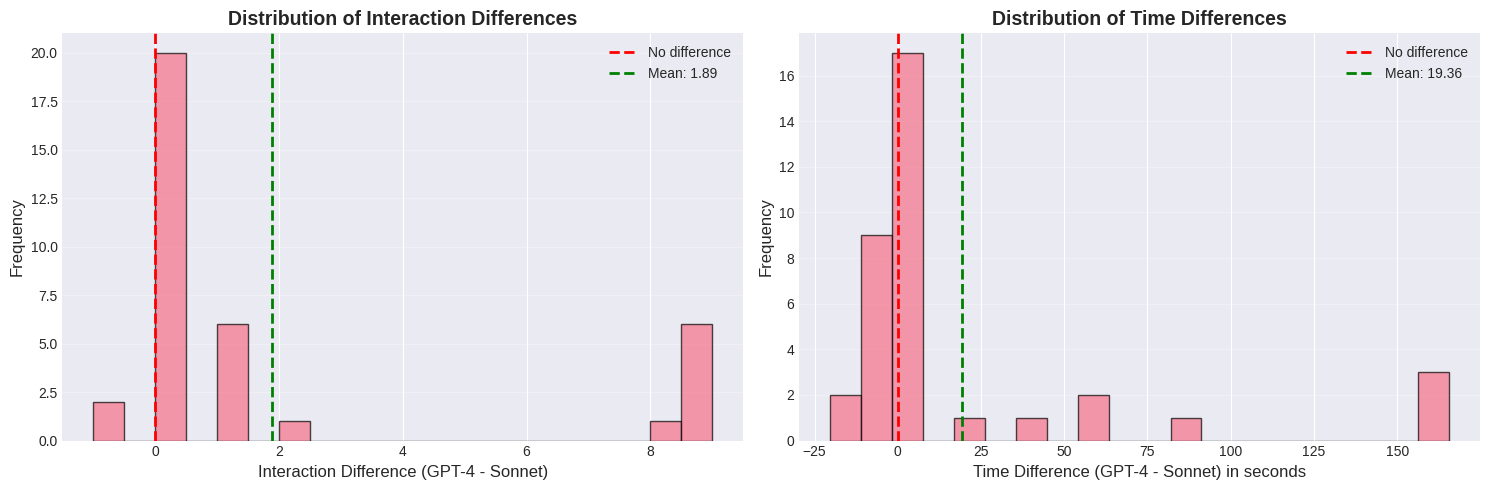


Distribution plots generated for 36 cases


In [15]:
# Visualization: Difference distributions
print("=" * 60)
print("VISUALIZATION - Difference Distributions")
print("=" * 60)

df_both_models = df_all.dropna(subset=['llm_interactions_gpt4', 'llm_interactions_sonnet', 
                                        'time_seconds_gpt4', 'time_seconds_sonnet'])

if len(df_both_models) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # 1. Interaction difference distribution
    ax1 = axes[0]
    ax1.hist(df_both_models['interaction_diff'], bins=20, edgecolor='black', alpha=0.7)
    ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No difference')
    ax1.axvline(x=df_both_models['interaction_diff'].mean(), color='green', 
                linestyle='--', linewidth=2, label=f'Mean: {df_both_models["interaction_diff"].mean():.2f}')
    ax1.set_xlabel('Interaction Difference (GPT-4 - Sonnet)', fontsize=12)
    ax1.set_ylabel('Frequency', fontsize=12)
    ax1.set_title('Distribution of Interaction Differences', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # 2. Time difference distribution
    ax2 = axes[1]
    ax2.hist(df_both_models['time_diff'], bins=20, edgecolor='black', alpha=0.7)
    ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No difference')
    ax2.axvline(x=df_both_models['time_diff'].mean(), color='green', 
                linestyle='--', linewidth=2, label=f'Mean: {df_both_models["time_diff"].mean():.2f}')
    ax2.set_xlabel('Time Difference (GPT-4 - Sonnet) in seconds', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Distribution of Time Differences', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nDistribution plots generated for {len(df_both_models)} cases")
else:
    print("No data available for visualization")
